# EDA Agrupación Raíz 

En este notebook se realizara un analisis exploratorio despues de las agrupaciones y de la limpeza de los datos a ver como se organizan los nuevos generos. En esta agrupación titulada **Raíz** se mantuvieron casi los mismos géneros solo se agruparon las variables estrictamente necesarias. Los grupos quedaron de la siguiene manera: 

|    | Categoría Final | Géneros Originales Incluidos                    | Concepto de Agrupación                                                            |
|----|-----------------|-------------------------------------------------|-----------------------------------------------------------------------------------|
| 1  | mainstream      | Pop, Dance, Rock, Alternative, Indie, R&B, Soul | Música de consumo masivo con alta producción y estructuras comerciales.           |
| 2  | hiphop          | Hip-Hop, Rap                                    | Géneros basados en el beat y el fraseo rítmico.                                   |
| 3  | electronic      | Electronic                                      | Música producida predominantemente con sintetizadores y DAWs.                     |
| 4  | jazz_blues      | Jazz, Blues                                     | Estilos con raíces afroamericanas basados en la improvisación y armonía compleja. |
| 5  | latin           | Reggaeton                                       | Ritmos latinos modernos de alta energía (urbano latino).                          |
| 6  | reggae          | Reggae, Ska                                     | Música de origen jamaicano con énfasis en el "off-beat".                          |
| 7  | clásico         | Classical, Opera                                | Música académica, orquestal y de tradición europea.                               |
| 8  | folk_country    | Folk, Country                                   | Estilos tradicionales basados en la narrativa y la instrumentación acústica.      |
| 9  | soundtrack      | Soundtrack, Movie, Anime                        | Composiciones diseñadas para acompañar medios visuales y narrativos.              |
| 10 | kids            | Children’s Music, Children's Music              | Contenido educativo o recreativo enfocado en público infantil.                    |
| 11 | comedy          | Comedy                                          | Performance vocal o musical enfocada en el humor.                                 |
| 12 | world           | World                                           | Música tradicional o folclórica de diversas regiones del mundo.                   |
| 13 | other           | Cualquier otro no listado                       | Categoría de seguridad para datos atípicos o no identificados.                    |


### Preprocesamiento 


In [2]:
import sys
import os
import importlib
import warnings
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import src.features.preprocessing as prep
importlib.reload(prep) 
df, x, y = prep.preprocessing()

df.head(5)

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,es_muy_larga,genre_grouped
0,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814,False,soundtrack
1,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816,False,soundtrack
2,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368,False,soundtrack
3,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227,False,soundtrack
4,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390,False,soundtrack


### Distribución de géneros 

Podemos observar que luego de reagrupar lo grupos hay un desbalanceo considerable de la variable Children's Music y el resto de variables que tenemos ahí. Así que antes de hacer los modelos tenemos que balancear los datos 


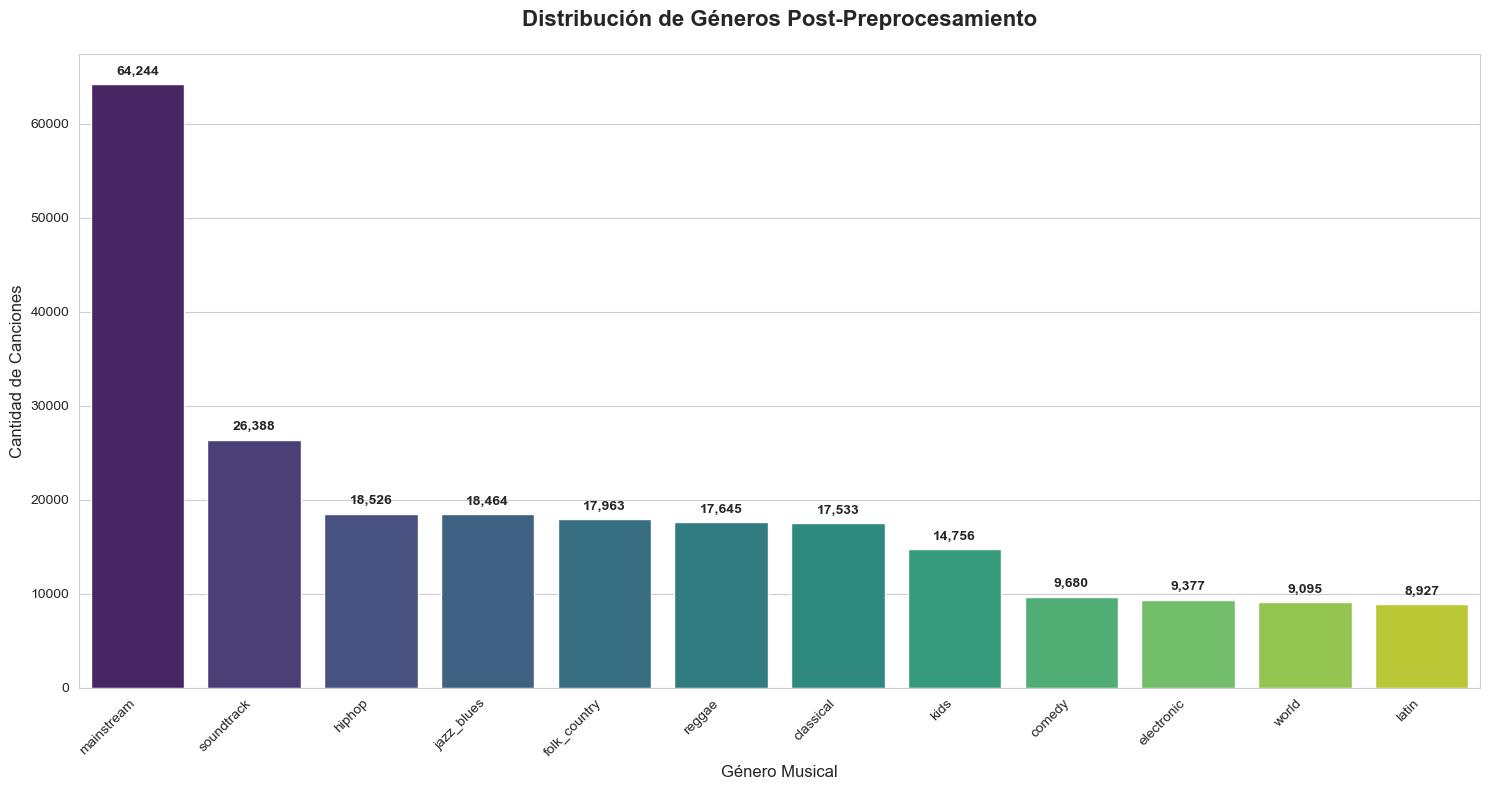

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

genre_counts = df['genre_grouped'].value_counts()

plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

ax = sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=10, fontweight='bold')
    
plt.title('Distribución de Géneros Post-Preprocesamiento', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Género Musical', fontsize=12)
plt.ylabel('Cantidad de Canciones', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [4]:
stats_despues = {
    'Num. Clases': df['genre_grouped'].nunique(),
    'Mínimo muestras': df['genre_grouped'].value_counts().min(),
    'Máximo muestras': df['genre_grouped'].value_counts().max(),
    'Promedio por clase': df['genre_grouped'].value_counts().mean()
}

stats_despues

{'Num. Clases': 12,
 'Mínimo muestras': 8927,
 'Máximo muestras': 64244,
 'Promedio por clase': np.float64(19383.166666666668)}

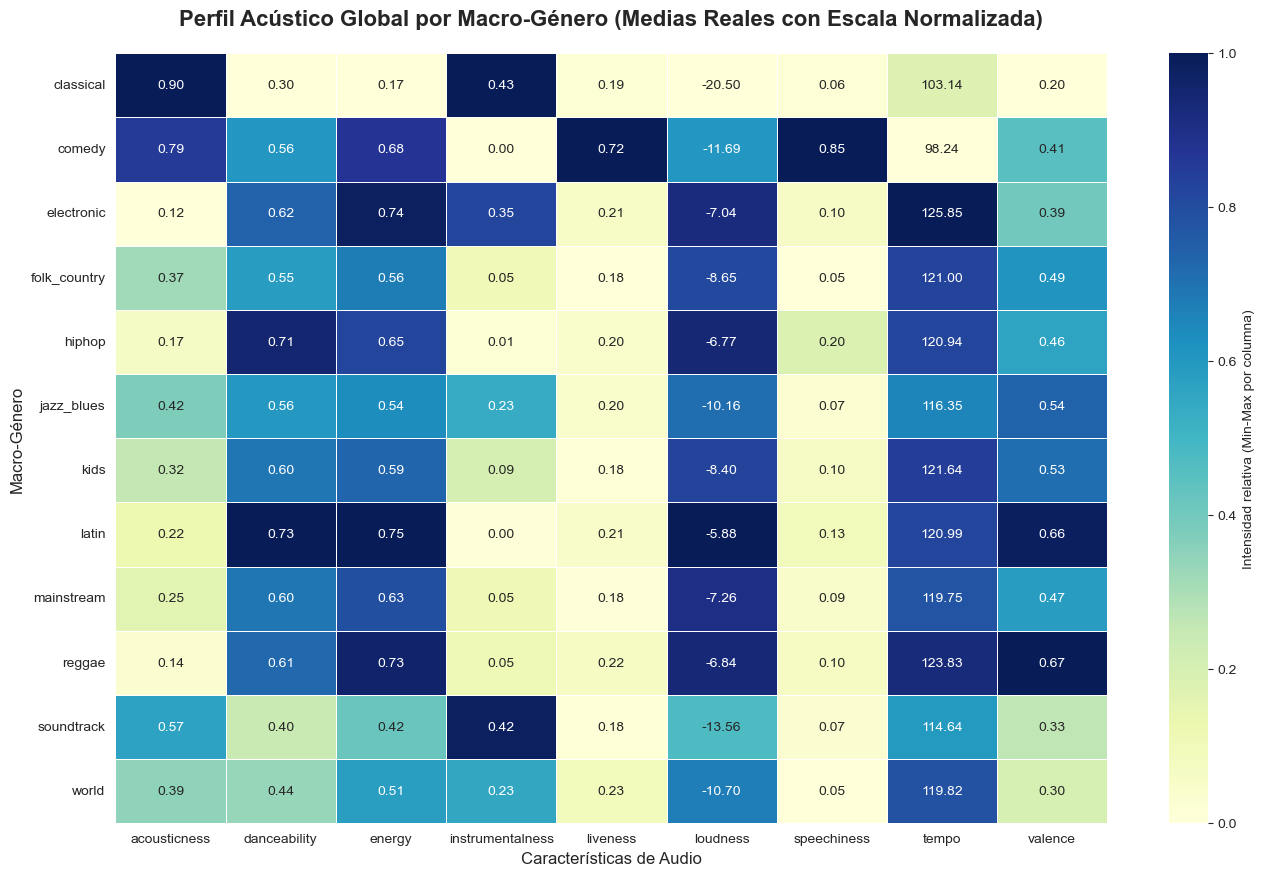

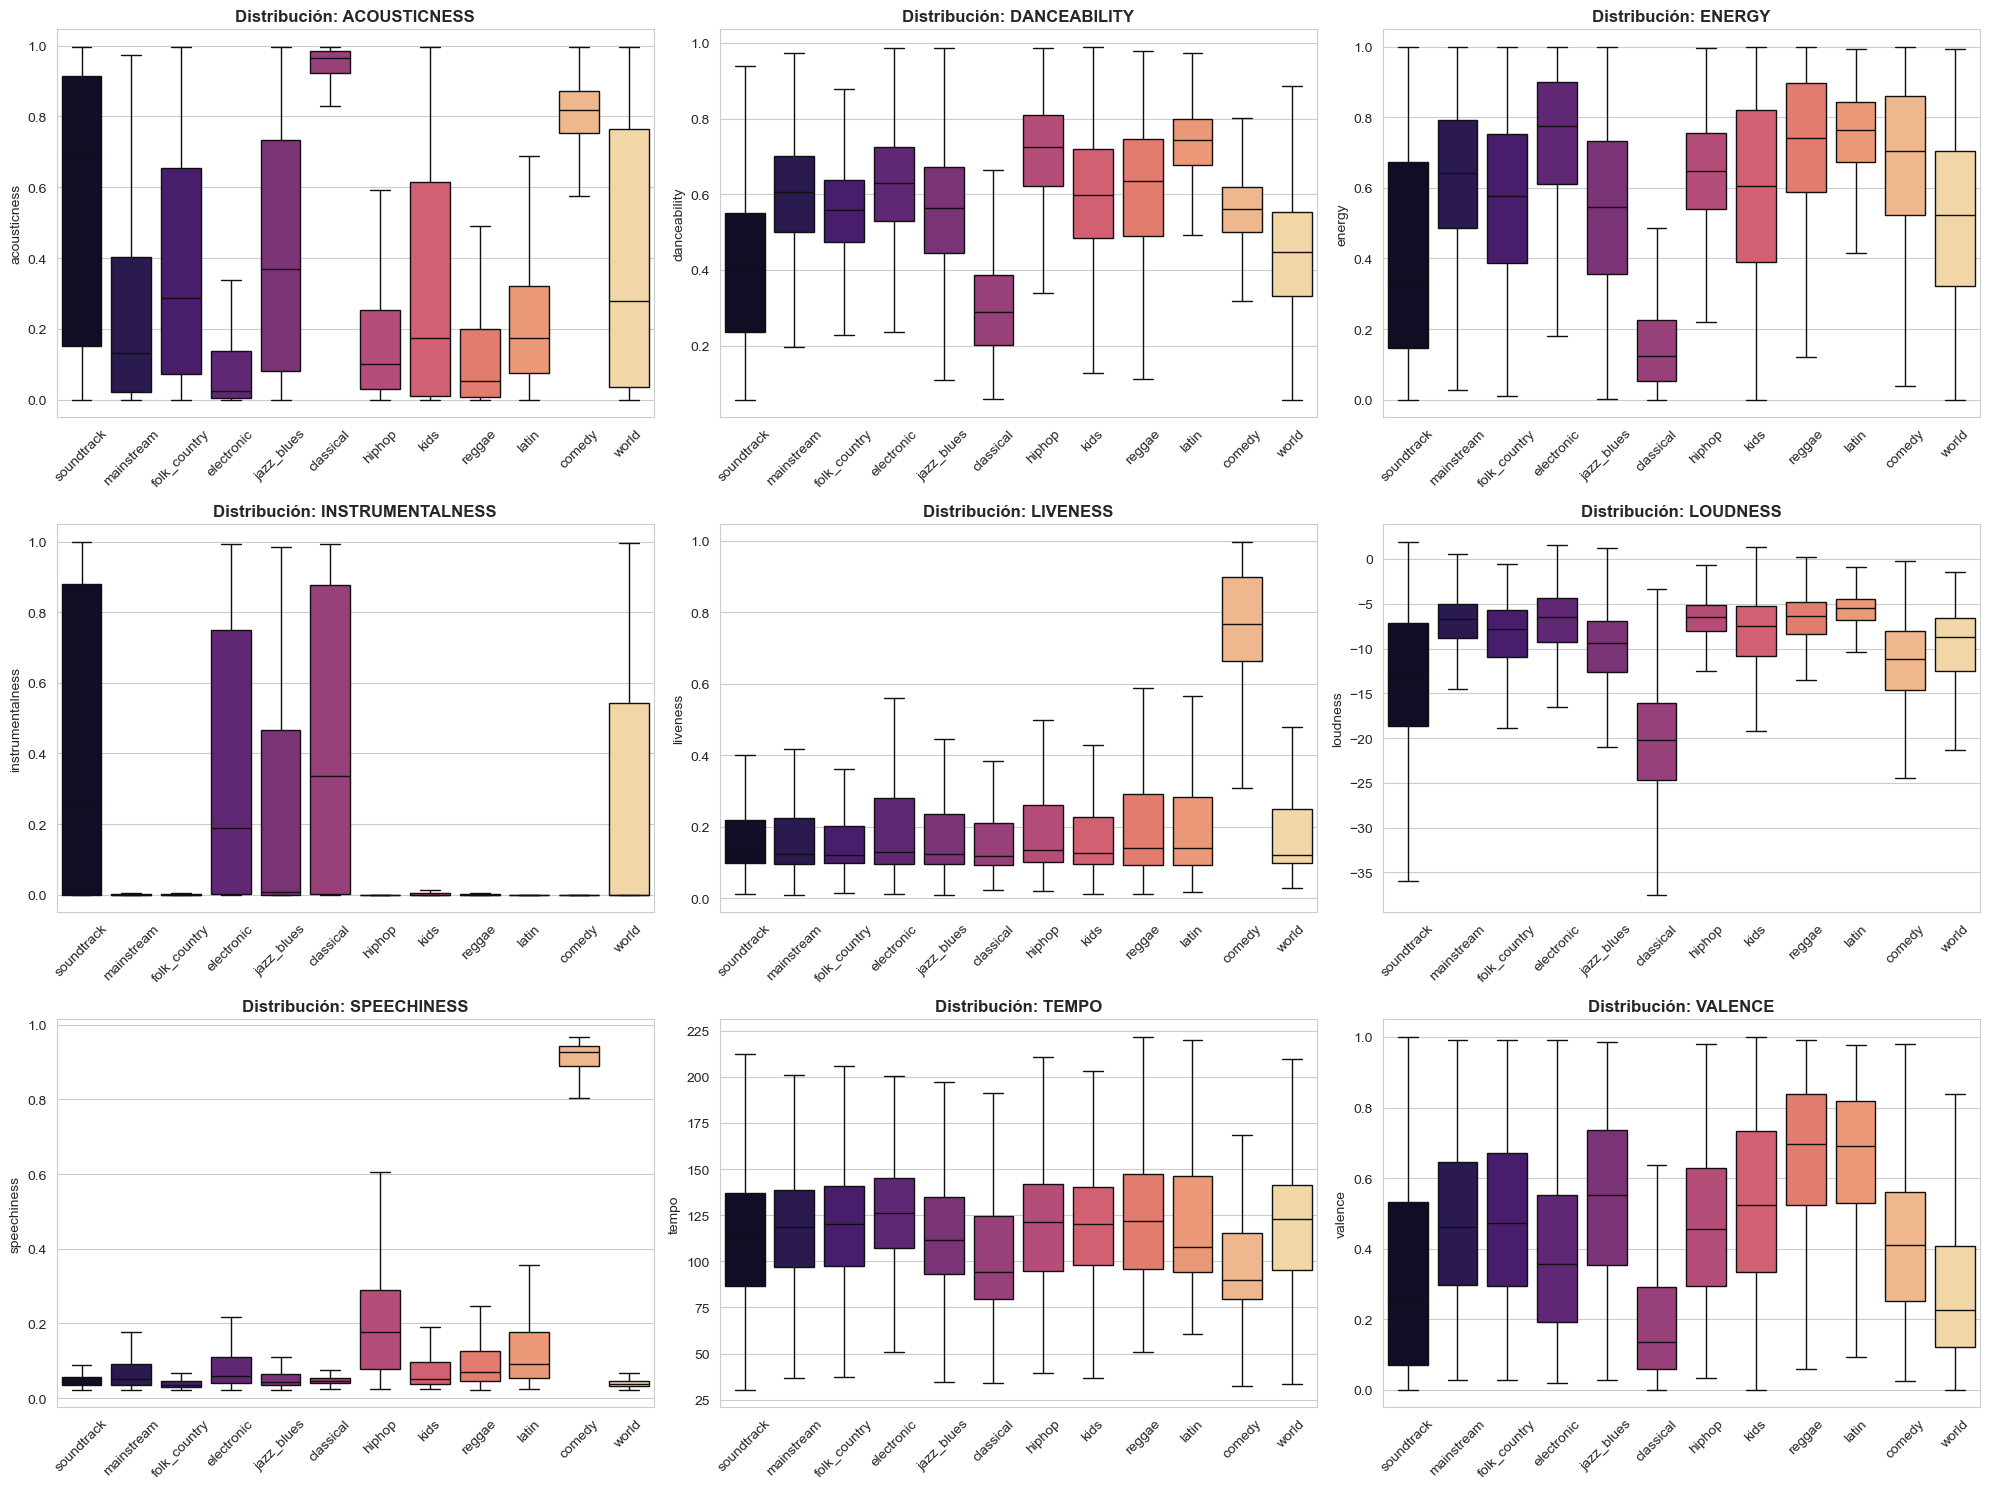

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Matriz de correlación para las variables numéricas
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
for col in ['duration_ms', 'key', 'mode', 'time_signature', 'popularity']:
    if col in cols_numericas: cols_numericas.remove(col)
perfil_medios = df.groupby('genre_grouped')[cols_numericas].mean()
perfil_norm = (perfil_medios - perfil_medios.min()) / (perfil_medios.max() - perfil_medios.min())

plt.figure(figsize=(16, 10))
sns.heatmap(perfil_norm, 
            annot=perfil_medios,
            fmt=".2f", 
            cmap='YlGnBu', 
            linewidths=.5,
            cbar_kws={'label': 'Intensidad relativa (Min-Max por columna)'})

plt.title('Perfil Acústico Global por Macro-Género (Medias Reales con Escala Normalizada)', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Macro-Género', fontsize=12)
plt.xlabel('Características de Audio', fontsize=12)
plt.show()

# Tablas de desviaciones estándar por macro-género




# Boxplots com respecto a 'genre_grouped_4' para cada variable numérica

n_cols = 3
n_rows = (len(cols_numericas) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    sns.boxplot(x='genre_grouped', y=col, data=df, ax=axes[i], palette='magma', showfliers=False)
    axes[i].set_title(f'Distribución: {col.upper()}', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

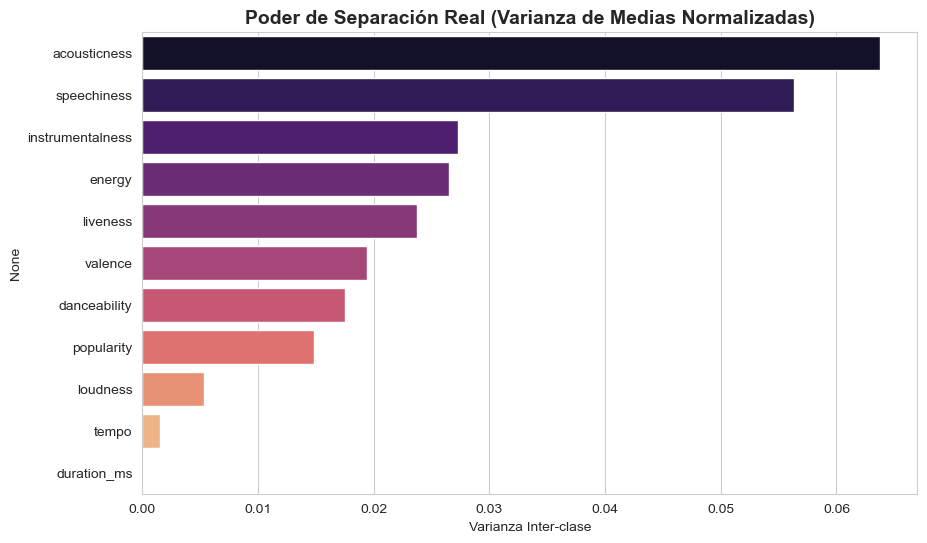

acousticness        0.063792
speechiness         0.056284
instrumentalness    0.027291
energy              0.026532
liveness            0.023760
valence             0.019432
danceability        0.017491
popularity          0.014879
loudness            0.005295
tempo               0.001528
duration_ms         0.000038
dtype: float64


In [8]:
from sklearn.preprocessing import MinMaxScaler

# 1. Seleccionamos solo las cuantitativas
cols_cuantitativas = df.select_dtypes(include=[np.number]).columns.tolist()

# 2. Normalizamos temporalmente para que todas valgan lo mismo (escala 0-1)
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[cols_cuantitativas]), columns=cols_cuantitativas)
df_scaled['genre_grouped'] = df['genre_grouped'].values

# 3. Calculamos la Varianza de las Medias
# Esto mide qué tanto se alejan los promedios de los grupos entre sí
ranking_separacion = df_scaled.groupby('genre_grouped').mean().var().sort_values(ascending=False)

# 4. Visualización
plt.figure(figsize=(10, 6))
sns.barplot(x=ranking_separacion.values, y=ranking_separacion.index, palette='magma')
plt.title('Poder de Separación Real (Varianza de Medias Normalizadas)', fontsize=14, fontweight='bold')
plt.xlabel('Varianza Inter-clase')
plt.show()

print(ranking_separacion)